# Чекпоинт 6

## **Импорты и функции**

In [12]:
!pip install -q sentence-transformers chromadb rank_bm25 groq python-dotenv tqdm tiktoken rouge-score

  Preparing metadata (setup.py) ... done


In [13]:
import ast, os, re, time, json, warnings, gc
from collections import defaultdict
from difflib import SequenceMatcher
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

import chromadb
import tiktoken
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder, InputExample, losses, util
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from torch.utils.data import DataLoader


from groq import Groq
from rouge_score import rouge_scorer

tqdm.pandas()

warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [14]:
def read_script(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def count_tokens(text: str) -> int:
    return len(enc.encode(text))

def chunk_text(text: str, chunk_size=400, overlap=50):
    tokens = enc.encode(text)
    chunks = []
    i = 0
    while i < len(tokens):
        j = min(i + chunk_size, len(tokens))
        chunk = enc.decode(tokens[i:j])
        chunks.append(chunk)
        i += chunk_size - overlap
    return chunks


def extract_role(line: str):
    m = re.match(r"^([A-Z][A-Z\s'\-]+):", line.strip())
    return m.group(1).strip() if m else None

def normalize_text(t):
    if not isinstance(t, str): return ''
    t = t.lower().strip()
    t = re.sub(r'\s+', ' ', t)
    t = re.sub(r"^[a-z\s']+:\s*", '', t)
    return t

def find_matching_lines(target_chunk, documents):
    if not isinstance(target_chunk, str): return None
    target = target_chunk.strip().lower()
    for doc in documents:
        if target in doc.lower(): return [doc]
    for i in range(len(documents) - 1):
        if target in (documents[i] + ' ' + documents[i+1]).lower():
            return [documents[i], documents[i+1]]
    best_score, best_doc = 0, None
    for doc in documents:
        s = SequenceMatcher(None, target, doc.lower()).ratio()
        if s > best_score: best_score, best_doc = s, doc
    return [best_doc] if best_score > 0.3 else None

def rouge_l_score(ref, hyp):
    rw = normalize_text(ref).split()
    hw = normalize_text(hyp).split()
    m, n = len(rw), len(hw)
    if m == 0 or n == 0: return 0.0
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = dp[i-1][j-1]+1 if rw[i-1]==hw[j-1] else max(dp[i-1][j], dp[i][j-1])
    lcs = dp[m][n]
    if lcs == 0: return 0.0
    p, r = lcs/n, lcs/m
    return 2*p*r/(p+r)

def f1_tokens(pred, ref):
    pt = set(normalize_text(pred).split())
    rt = set(normalize_text(ref).split())
    if not pt or not rt: return 0.0
    c = pt & rt
    if not c: return 0.0
    p, r = len(c)/len(pt), len(c)/len(rt)
    return 2*p*r/(p+r)

def encode_corpus(model, texts, batch_size=64, prefix=''):
    if prefix:
        texts = [prefix + t for t in texts]
    embs = model.encode(texts, batch_size=batch_size, convert_to_numpy=True,
                        normalize_embeddings=True, show_progress_bar=False)
    return embs

def eval_dense_retriever(name, model, documents, val_df, top_k=5,
                         q_prefix='', d_prefix='', doc_embs=None):
    t0 = time.time()
    if doc_embs is None:
        doc_embs = encode_corpus(model, documents, prefix=d_prefix)
    idx_t = time.time() - t0

    t0 = time.time()
    qs = [q_prefix + q for q in val_df['question'].tolist()]
    q_embs = model.encode(qs, batch_size=64, convert_to_numpy=True,
                          normalize_embeddings=True, show_progress_bar=False)
    # cosine = dot для нормализованных
    sims = q_embs @ doc_embs.T  # (Nq, Nd)

    top1_l, topk_l, sim_l = [], [], []
    for i, row in val_df.iterrows():
        rc = row['right_chunk']
        rl = find_matching_lines(rc, documents)
        if rl is None: rl = [rc] if isinstance(rc, str) else []
        rn = [normalize_text(r) for r in rl]

        idx = np.argsort(-sims[i])[:top_k]
        chunks = [documents[j] for j in idx]
        cn = [normalize_text(c) for c in chunks]
        top1_l.append(int(cn[0] in rn) if cn else 0)
        topk_l.append(int(any(c in rn for c in cn)))
        sim_l.append(float(np.mean(sims[i][idx])))

    dt = time.time() - t0
    return ({
        'Эксперимент': name,
        'Top-1 Acc.': round(np.mean(top1_l), 4),
        'Top-K Acc.': round(np.mean(topk_l), 4),
        'Retr. Sem. Sim.': round(np.mean(sim_l), 4),
        'Время поиска (сек)': round(dt, 1),
        'Время индексации (сек)': round(idx_t, 1),
    }, doc_embs)

## **Текущая архитектура**

Сначала вспомним, какая исходная архитектура нашего проекта. В основе интерактивной игры лежит RAG-система:

1) Пользователь вводит запрос (эмбеддинг запроса: all-MiniLM-L6-v2 - это distilled-transformer, у модели 6 слоёв, 384-dim)

2) Далее для ответа на вопрос осуществляется векторный поиск релевантных чанков через Chroma:
- корпус: script_augmented.txt (1-й сезон BoJack + синтетические диалоги, сгенерированные Gemini 3 Pro Preview), язык - английский
- чанков всего: 553
- параметры чанков: разбиение чанков происходит по репликам (max chunk_size = 400), overlap 50
- возвращается top-5 чанков

3)Генерация ответа персонажем. Найденные top-5 чанков подаются в LLM llama-3.1-8b-instant через Groq API с системным промптом «отвечай в стиле персонажа BoJack Horseman, опираясь только на контекст....», temperature = 0.7.


### Что было добавлено по результатам чекпоинта 5

В Чекпойнте 5 эмбеддер (MiniLM-L6) и генератор (Llama-3.1-8B) оставлены без изменений, тк улучшался алгоритм поиска. В результате проведения экспериментов и замеров влияния парамтеров на итоговые метрики в пайплайн было добавлено одно изменение, имеющее положительное влияние: Hybrid-поиск через Reciprocal Rank Fusion (BM25 + Dense) (α=0.5 + K-7)

## **Текущие метрики**

### Загрузка данных

In [24]:
CHUNK_SIZE = 400
CHUNK_OVERLAP = 50
TOP_K = 5

# модель для эмбеддингов
MODEL_NAME = "all-MiniLM-L6-v2"
enc = tiktoken.get_encoding("cl100k_base")
embedder = SentenceTransformer(MODEL_NAME)

# оценщик, который будем использовать при подсчёте метрик на генерации
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
SCRIPT_PATH = 'script_augmented.txt'
CHROMA_PATH = "./chroma_augmented_store"
COLLECTION_NAME = "bojack_script"

client = chromadb.PersistentClient(path=CHROMA_PATH)
collection = client.get_or_create_collection(name=COLLECTION_NAME)

text = read_script(SCRIPT_PATH)

paragraphs = [p.strip() for p in text.split("\n") if p.strip()]

documents = []
metadatas = []
ids = []

chunk_id = 0

for i, para in enumerate(paragraphs):
    role = extract_role(para)
    chunks = chunk_text(para, CHUNK_SIZE, CHUNK_OVERLAP)
    for j, ch in enumerate(chunks):
        tok = count_tokens(ch)
        documents.append(ch)
        metadatas.append({
            "role": role or "UNKNOWN",
            "source_para": i,
            "chunk": j,
            "tokens": tok
        })
        ids.append(f"chunk-{chunk_id}")
        chunk_id += 1

embeddings = embedder.encode(documents, show_progress_bar=True).tolist()

collection.add(documents=documents, embeddings=embeddings, metadatas=metadatas, ids=ids)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

### Пересчёт метрик

In [29]:
DATA_DIR = '../checkpoint_3'
val_df = pd.read_excel(f'{DATA_DIR}/valid_dataset.xlsx')
val_df = val_df.dropna(subset=['question', 'right_answer', 'right_chunk'])
val_df = val_df.drop_duplicates(subset=['question']).reset_index(drop=True)

In [27]:
client = chromadb.PersistentClient(path=f'{DATA_DIR}/chroma_augmented_store')
col = client.get_collection('bojack_script')
docs = col.get(include=['documents'])['documents']

In [30]:
print(f'Корпус: {len(docs)} чанков | Валидация: {len(val_df)} вопросов')

Корпус: 553 чанков | Валидация: 222 вопросов


In [31]:
bm25 = BM25Okapi([d.lower().split() for d in docs])

def normalize(t):
    if not isinstance(t, str): return ''
    t = re.sub(r'\s+', ' ', t.lower().strip())
    return re.sub(r"^[a-z\s']+:\s*", '', t)

def find_matching_lines(target, documents):
    if not isinstance(target, str): return None
    t = target.strip().lower()
    for d in documents:
        if t in d.lower(): return [d]
    for i in range(len(documents) - 1):
        if t in (documents[i] + ' ' + documents[i+1]).lower():
            return [documents[i], documents[i+1]]
    best, doc = 0, None
    for d in documents:
        s = SequenceMatcher(None, t, d.lower()).ratio()
        if s > best: best, doc = s, d
    return [doc] if best > 0.3 else None

def rouge_l(ref, hyp):
    rw, hw = normalize(ref).split(), normalize(hyp).split()
    m, n = len(rw), len(hw)
    if not m or not n: return 0.0
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1, m+1):
        for j in range(1, n+1):
            dp[i][j] = dp[i-1][j-1]+1 if rw[i-1]==hw[j-1] else max(dp[i-1][j], dp[i][j-1])
    lcs = dp[m][n]
    if not lcs: return 0.0
    p, r = lcs/n, lcs/m
    return 2*p*r/(p+r)

def f1_tok(pred, ref):
    pt, rt = set(normalize(pred).split()), set(normalize(ref).split())
    if not pt or not rt: return 0.0
    c = pt & rt
    if not c: return 0.0
    p, r = len(c)/len(pt), len(c)/len(rt)
    return 2*p*r/(p+r)

def retrieve_semantic(q, k=5):
    res = col.query(query_texts=[q], n_results=k, include=['documents', 'distances'])
    return res['documents'][0], res['distances'][0]

def retrieve_hybrid(q, k=7, alpha=0.5):
    K_rrf, nc = 60, min(k*3, len(docs))
    sem = col.query(query_texts=[q], n_results=nc, include=['documents', 'distances'])
    sem_docs, sem_dists = sem['documents'][0], sem['distances'][0]
    bs = bm25.get_scores(q.lower().split())
    bm_docs = [docs[i] for i in np.argsort(bs)[::-1][:nc]]
    scores = defaultdict(float)
    for r, d in enumerate(sem_docs): scores[d] += alpha/(K_rrf+r+1)
    for r, d in enumerate(bm_docs):  scores[d] += (1-alpha)/(K_rrf+r+1)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
    chunks = [d for d, _ in ranked]
    sem_map = dict(zip(sem_docs, sem_dists))
    dists = [sem_map.get(c, 2.0) for c in chunks]
    return chunks, dists

def eval_retrieval(name, retrieve_fn):
    t0 = time.time()
    top1, topk, sim = [], [], []
    for _, row in val_df.iterrows():
        rc = row['right_chunk']
        rl = find_matching_lines(rc, docs) or ([rc] if isinstance(rc, str) else [])
        rn = [normalize(r) for r in rl]
        chunks, dists = retrieve_fn(row['question'])
        cn = [normalize(c) for c in chunks]
        top1.append(int(cn[0] in rn) if cn else 0)
        topk.append(int(any(c in rn for c in cn)))
        sim.append(float(np.mean([1/(1+d) for d in dists])) if dists else 0.0)
    dt = time.time() - t0
    return {
        'name': name,
        'Top-1': round(np.mean(top1), 4),
        'Top-K': round(np.mean(topk), 4),
        'Retr.Sim': round(np.mean(sim), 4),
        'time_s': round(dt, 1),
    }

print('Retrieval (на augmented корпусе)')
r1 = eval_retrieval('Baseline (Semantic K=5, Чекпойнт 3)', lambda q: retrieve_semantic(q, 5))
r2 = eval_retrieval('Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)', lambda q: retrieve_hybrid(q, 7, 0.5))
pd.DataFrame([r1, r2])

Retrieval (на augmented корпусе)


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:02<00:00, 31.6MiB/s]


,name,Top-1,Top-K,Retr.Sim,time_s
0,"Baseline (Semantic K=5, Чекпойнт 3)",0.2162,0.3829,0.5647,76.5
1,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",0.1712,0.4685,0.5002,75.7


Теперь посчитаем метрики генерации:

In [34]:
GROQ_API_KEY = ""
model = Groq(api_key=GROQ_API_KEY)
emb_eval = SentenceTransformer('all-MiniLM-L6-v2')

# кэширую (doc, meta) для BM25
_all = col.get(include=['documents', 'metadatas'])
DOC2META = dict(zip(_all['documents'], _all['metadatas']))

def retrieve_chunks_semantic(query, n_results=5):
    res = col.query(query_texts=[query], n_results=n_results,
                    include=['documents', 'metadatas'])
    return res['documents'][0], res['metadatas'][0]

def retrieve_chunks_hybrid(query, n_results=7, alpha=0.5):
    K_rrf, nc = 60, min(n_results * 3, len(docs))
    sem = col.query(query_texts=[query], n_results=nc,
                    include=['documents', 'metadatas'])
    sem_docs = sem['documents'][0]
    bs = bm25.get_scores(query.lower().split())
    bm_docs = [docs[i] for i in np.argsort(bs)[::-1][:nc]]

    scores = defaultdict(float)
    for r, d in enumerate(sem_docs): scores[d] += alpha / (K_rrf + r + 1)
    for r, d in enumerate(bm_docs):  scores[d] += (1 - alpha) / (K_rrf + r + 1)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n_results]
    out_docs  = [d for d, _ in ranked]
    out_metas = [DOC2META[d] for d in out_docs]
    return out_docs, out_metas

# код для подсчёта метрик такой же, как в и в тетрдке по чекпоинту 3
# где мы считали generation-метрики для бейзлайна
def build_context(chunks, metas):
    context = ""
    for doc, meta in zip(chunks, metas):
        role = meta.get("role", "UNKNOWN")
        context += f"{role}: {doc}\n"
    return context

def generate_answer(query, chunks_context, max_new_tokens=300):
    prompt = f"""
        Answer the question below based on the context.
        Do not hallucinate; only use information from the context.

        Context:
        {chunks_context}

        Question:
        {query}

        Answer:
    """
    output = model.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=600,
        temperature=0.7,
    )
    return output.choices[0].message.content.strip()


def gen_sim_metric(pred, ref):
    if not pred or not ref: return 0.0
    e = emb_eval.encode([pred, ref], normalize_embeddings=True, show_progress_bar=False)
    return float(np.dot(e[0], e[1]))

def eval_generation(name, retrieve_fn, sleep_s=0.3):
    t0 = time.time()
    em, f1, sim, rl, lat = [], [], [], [], []
    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc=name):
        chunks, metas = retrieve_fn(row['question'])
        context = build_context(chunks, metas)
        ts = time.time()
        try:
            ans = generate_answer(row['question'], context)
        except Exception as e:
            print(f'  err: {e}'); ans = ''
        lat.append(time.time() - ts)
        ref = row['right_answer']
        em.append(int(normalize(ans) == normalize(ref)))
        f1.append(f1_tok(ans, ref))
        sim.append(gen_sim_metric(ans, ref))
        rl.append(rouge_l(ref, ans))
        time.sleep(sleep_s)
    return {
        'name':            name,
        'Exact Match':     round(np.mean(em), 4),
        'F1':              round(np.mean(f1), 4),
        'Gen.Sim':         round(np.mean(sim), 4),
        'ROUGE-L':         round(np.mean(rl), 4),
        'Avg latency (с)': round(np.mean(lat), 2),
        'time_s':          round(time.time() - t0, 1),
    }


print('Подсчёт generation-метрик')
g1 = eval_generation(
    'Baseline (Semantic K=5) + Llama-3.1-8B',
    lambda q: retrieve_chunks_semantic(q, n_results=5),
)
g2 = eval_generation(
    'Best ML (Hybrid α=0.5, K=7) + Llama-3.1-8B',
    lambda q: retrieve_chunks_hybrid(q, n_results=7, alpha=0.5),
)
pd.DataFrame([g1, g2])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Подсчёт generation-метрик


Best ML (Hybrid α=0.5, K=7) + Llama-3.1-8B: 100%|██████████| 222/222 [10:57<00:00,  2.96s/it]


,name,Exact Match,F1,Gen.Sim,ROUGE-L,Avg latency (с),time_s
0,Baseline (Semantic K=5) + Llama-3.1-8B,0.0225,0.1447,0.3219,0.1304,2.14,606.0
1,"Best ML (Hybrid α=0.5, K=7) + Llama-3.1-8B",0.0360,0.1626,0.3553,0.1461,2.37,657.6


In [40]:
# сюда будем складывать все результаты
all_results = [{
    'Эксперимент': 'Baseline (Semantic K=5, Чекпойнт 3)',
    'Корпус': 'chroma_augmented_store',
    'Retrieval': 'Semantic, MiniLM-L6, K=5',
    'LLM': 'llama-3.1-8b-instant (temp=0.7)',

    'Top-1 Acc.': 0.2162,
    'Top-K Acc.': 0.3829,
    'Retr. Sem. Sim.': 0.5647,

    'Exact Match': 0.0225,
    'F1': 0.1447,
    'Gen. Sem. Sim.': 0.3219, # главная метрика
    'ROUGE-L': 0.1304,

    'Avg latency (сек)': 2.14,
    'Время поиска (сек)': 76.5,
    'Время индексации (сек)': None,

    'Модель': 'all-MiniLM-L6-v2',
    },
    {
      'Эксперимент': 'Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)',
      'Корпус': 'chroma_augmented_store',
      'Retrieval': 'Hybrid RRF, α=0.5, K=7',
      'LLM': 'llama-3.1-8b-instant (temp=0.7)',

      'Top-1 Acc.': 0.1712,
      'Top-K Acc.': 0.4685,
      'Retr. Sem. Sim.': 0.5002,

      'Exact Match': 0.0360,
      'F1': 0.1626,
      'Gen. Sem. Sim.': 0.3553,
      'ROUGE-L': 0.1461,

      'Avg latency (сек)': 2.37,
      'Время поиска (сек)': 75.7,
      'Время индексации (сек)': None,

      'Модель': 'all-MiniLM-L6-v2',
    },
]

pd.DataFrame(all_results)

,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек)
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,None
1,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",chroma_augmented_store,"Hybrid RRF, α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.1712,0.4685,0.5002,0.0360,0.1626,0.3553,0.1461,2.37,75.7,None


# **План экспериментов в рамках чекпоинта 6**

1. **Biencoder embeddings** — сравнение трансформеров: MiniLM (baseline) vs MPNet vs BGE
2. **Cross-encoder reranker** — протестировать, улучшает ли качество применение кросс-энкодера, ранжирующего найденные чанки (тогда вытаскивать из БД нужно больше чанков)
3. **Сравнение LLM, используюемых для генерации реплик** — Llama-3.1-8B vs Llama-3.3-70B vs OpenAI GPT-OSS-120B через Groq API

## Главные метрики (выбраны и обоснованы в чекпоинте 3)
- (для оценивания качества генерации) **Generation Semantic Similarity**
- (для оценивания качества извлечения чанков) **Retrieval Top-K Accuracy**


# Эксперимент 1 — Сравнение моделей-эмбеддеров

В рамках этого эксперименты протестируем, как выбор модели-эмбеддера влияет на метрики поиска.

**Сравниваемые модели:**
| Модель | Слои | dim | Особенность |
|---|---|---|---|
| `all-MiniLM-L6-v2` (baseline) | 6 | 384 | компактная, MiniLM-distilled |
| `all-mpnet-base-v2` | 12 | 768 | MPNet, общий-purpose, сильнее MiniLM |
| `BAAI/bge-base-en-v1.5` | 12 | 768 | contrastive-обучение на retrieval |

In [41]:
def eval_dense_retriever(name, model, documents, val_df, top_k=5):
    t0 = time.time()
    doc_embs = model.encode(documents, batch_size=64, convert_to_numpy=True,
                            normalize_embeddings=True, show_progress_bar=False)
    idx_t = time.time() - t0

    t0 = time.time()
    qs = val_df['question'].tolist()
    q_embs = model.encode(qs, batch_size=64, convert_to_numpy=True,
                          normalize_embeddings=True, show_progress_bar=False)
    sims = q_embs @ doc_embs.T

    top1, topk, sim_list = [], [], []
    for i, row in val_df.iterrows():
        rc = row['right_chunk']
        rl = find_matching_lines(rc, documents) or ([rc] if isinstance(rc, str) else [])
        rn = [normalize(r) for r in rl]
        idx = np.argsort(-sims[i])[:top_k]
        chunks = [documents[j] for j in idx]
        cn = [normalize(c) for c in chunks]
        top1.append(int(cn[0] in rn) if cn else 0)
        topk.append(int(any(c in rn for c in cn)))
        sim_list.append(float(np.mean(sims[i][idx])))
    dt = time.time() - t0

    return {
        'Эксперимент': name,
        'Top-1 Acc.': round(np.mean(top1), 4),
        'Top-K Acc.': round(np.mean(topk), 4),
        'Retr. Sem. Sim.': round(np.mean(sim_list), 4),
        'Время индексации (сек)': round(idx_t, 1),
        'Время поиска (сек)': round(dt, 1),
    }, doc_embs

In [43]:
EMB_MODELS = [
    ('MPNet-base', 'sentence-transformers/all-mpnet-base-v2'),
    ('BGE-base-en-v1.5', 'BAAI/bge-base-en-v1.5'),
]

emb_results = []
emb_doc_embs_cache = {}

for name, path in EMB_MODELS:
    print(f'\n{name} ({path}) ===')
    try:
        model = SentenceTransformer(path, device=device)
        m, doc_embs = eval_dense_retriever(
            f'Emb: {name}', model, docs, val_df, top_k=5,
        )
        m['Модель'] = path
        emb_results.append(m)
        emb_doc_embs_cache[name] = (model, doc_embs)
        print(f'Top-1={m["Top-1 Acc."]:.4f} | Top-K={m["Top-K Acc."]:.4f} | '
              f'Sim={m["Retr. Sem. Sim."]:.4f} | '
              f'idx={m["Время индексации (сек)"]}s | search={m["Время поиска (сек)"]}s')
    except Exception as e:
        print(f'Ошибка: {e}')

all_results.extend(emb_results)

pd.DataFrame([all_results[1]] + emb_results)[[
    'Эксперимент', 'Top-1 Acc.', 'Top-K Acc.', 'Retr. Sem. Sim.',
    'Время индексации (сек)', 'Время поиска (сек)',
]]


MPNet-base (sentence-transformers/all-mpnet-base-v2) ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Top-1=0.2387 | Top-K=0.3964 | Sim=0.5954 | idx=1.1s | search=10.9s

BGE-base-en-v1.5 (BAAI/bge-base-en-v1.5) ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Top-1=0.2973 | Top-K=0.4369 | Sim=0.6892 | idx=0.9s | search=11.1s


,Эксперимент,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Время индексации (сек),Время поиска (сек)
0,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",0.1712,0.4685,0.5002,NaN,75.7
1,Emb: MPNet-base,0.2387,0.3964,0.5954,1.1,10.9
2,Emb: BGE-base-en-v1.5,0.2973,0.4369,0.6892,0.9,11.1


In [49]:
all_results[2]['Корпус'] = 'chroma_augmented_store'
all_results[3]['Корпус'] = 'chroma_augmented_store'

all_results[2]['Retrieval'] = 'Semantic, MiniLM-L6, K=5'
all_results[3]['Retrieval'] = 'Semantic, MiniLM-L6, K=5'

In [50]:
pd.DataFrame(all_results)

,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек),Модель
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,NaN,all-MiniLM-L6-v2
1,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",chroma_augmented_store,"Hybrid RRF, α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.1712,0.4685,0.5002,0.0360,0.1626,0.3553,0.1461,2.37,75.7,NaN,all-MiniLM-L6-v2
2,Emb: MPNet-base,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2387,0.3964,0.5954,NaN,NaN,NaN,NaN,NaN,10.9,1.1,sentence-transformers/all-mpnet-base-v2
3,Emb: BGE-base-en-v1.5,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2973,0.4369,0.6892,NaN,NaN,NaN,NaN,NaN,11.1,0.9,BAAI/bge-base-en-v1.5


По метрике retrieval semantics sim. видно, что лидирует модель BGE-base. Поэтому теперь прогоним вариант BGE-base + best ml, заменив обычный семантический поиск на гибридный:

In [57]:
GROQ_API_KEY = ""
model = Groq(api_key=GROQ_API_KEY)

bge_model, bge_doc_embs = emb_doc_embs_cache['BGE-base-en-v1.5']

_all = col.get(include=['documents', 'metadatas'])
DOC2META = dict(zip(_all['documents'], _all['metadatas']))

def retrieve_hybrid_bge(query, n_results=7, alpha=0.5):
    """
    Hybrid RRF (BM25 + BGE-base dense)
    """
    K_rrf, nc = 60, min(n_results * 3, len(docs))

    # поиск через BGE (тк у Chroma встроен MiniLM)
    q_emb = bge_model.encode([query], normalize_embeddings=True,
                              show_progress_bar=False)[0]
    sem_sims_all = q_emb @ bge_doc_embs.T
    sem_idx = np.argsort(-sem_sims_all)[:nc]
    sem_docs = [docs[i] for i in sem_idx]

    # BM25
    bs = bm25.get_scores(query.lower().split())
    bm_idx = np.argsort(-bs)[:nc]
    bm_docs = [docs[i] for i in bm_idx]

    # RRF
    scores = defaultdict(float)
    for r, d in enumerate(sem_docs): scores[d] += alpha     / (K_rrf + r + 1)
    for r, d in enumerate(bm_docs):  scores[d] += (1 - alpha) / (K_rrf + r + 1)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n_results]
    out_docs = [d for d, _ in ranked]

    doc_to_idx = {d: i for i, d in enumerate(docs)}
    out_sims  = [float(sem_sims_all[doc_to_idx[d]]) for d in out_docs]
    out_metas = [DOC2META[d] for d in out_docs]
    return out_docs, out_sims, out_metas

def eval_retrieval_bge(name, retrieve_fn):
    t0 = time.time()
    top1, topk, sim = [], [], []
    for _, row in val_df.iterrows():
        rc = row['right_chunk']
        rl = find_matching_lines(rc, docs) or ([rc] if isinstance(rc, str) else [])
        rn = [normalize(r) for r in rl]
        chunks, sims, _ = retrieve_fn(row['question'])
        cn = [normalize(c) for c in chunks]
        top1.append(int(cn[0] in rn) if cn else 0)
        topk.append(int(any(c in rn for c in cn)))
        sim.append(float(np.mean(sims)) if sims else 0.0)
    return {
        'Эксперимент': 'Emb: BGE-base + Hybrid α=0.5 K=7 (retrieval)',
        'Top-1 Acc.': round(np.mean(top1), 4),
        'Top-K Acc.': round(np.mean(topk), 4),
        'Retr. Sem. Sim.': round(np.mean(sim), 4),
        'Время поиска (сек)': round(time.time() - t0, 1),
    }


def eval_generation_bge(name, retrieve_fn, sleep_s=0.3):
    t0 = time.time()
    em, f1, sim, rl, lat = [], [], [], [], []
    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc=name):
        chunks, _, metas = retrieve_fn(row['question'])
        context = build_context(chunks, metas)
        ts = time.time()
        try:
            ans = generate_answer(row['question'], context)
        except Exception as e:
            print(f'  err: {e}'); ans = ''
        lat.append(time.time() - ts)
        ref = row['right_answer']
        em.append(int(normalize(ans) == normalize(ref)))
        f1.append(f1_tok(ans, ref))
        sim.append(gen_sim_metric(ans, ref))
        rl.append(rouge_l(ref, ans))
        time.sleep(sleep_s)
    return {
        'Эксперимент': name,
        'Exact Match': round(np.mean(em), 4),
        'F1': round(np.mean(f1), 4),
        'Gen. Sem. Sim.': round(np.mean(sim), 4),
        'ROUGE-L': round(np.mean(rl), 4),
        'Avg latency (сек)': round(np.mean(lat), 2),
        'Время поиска (сек)': round(time.time() - t0, 1),
    }


print('Retrieval (BGE-base + Hybrid α=0.5 K=7)')
retr_bge_hybrid = eval_retrieval_bge(
    'BGE + Hybrid α=0.5 K=7',
    lambda q: retrieve_hybrid_bge(q, n_results=7, alpha=0.5),
)
print(retr_bge_hybrid)

print('\nGeneration (BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B temp=0.7)')
gen_bge_hybrid = eval_generation_bge(
    'BGE + Hybrid α=0.5 K=7 + Llama-3.1-8B',
    lambda q: retrieve_hybrid_bge(q, n_results=7, alpha=0.5),
)
print(gen_bge_hybrid)

bge_hybrid_full = {
    'Эксперимент': 'BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B',
    'Корпус': 'chroma_augmented_store',
    'Retrieval': 'Hybrid RRF (BM25 + BGE-base dense), α=0.5, K=7',
    'LLM': 'llama-3.1-8b-instant (temp=0.7)',

    'Top-1 Acc.': retr_bge_hybrid['Top-1 Acc.'],
    'Top-K Acc.': retr_bge_hybrid['Top-K Acc.'],
    'Retr. Sem. Sim.': retr_bge_hybrid['Retr. Sem. Sim.'],

    'Exact Match': gen_bge_hybrid['Exact Match'],
    'F1': gen_bge_hybrid['F1'],
    'Gen. Sem. Sim.': gen_bge_hybrid['Gen. Sem. Sim.'],
    'ROUGE-L': gen_bge_hybrid['ROUGE-L'],
    'Avg latency (сек)': gen_bge_hybrid['Avg latency (сек)'],
    'Время поиска (сек)': retr_bge_hybrid['Время поиска (сек)'],
    'Время индексации (сек)': None,
    'Модель': 'BAAI/bge-base-en-v1.5'
}
all_results.append(bge_hybrid_full)
pd.DataFrame([all_results[0], all_results[1], bge_hybrid_full])  # baseline + best ML + new

Retrieval (BGE-base + Hybrid α=0.5 K=7)
{'Эксперимент': 'Emb: BGE-base + Hybrid α=0.5 K=7 (retrieval)', 'Top-1 Acc.': np.float64(0.2117), 'Top-K Acc.': np.float64(0.5), 'Retr. Sem. Sim.': np.float64(0.6421), 'Время поиска (сек)': 15.2}

Generation (BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B temp=0.7)


BGE + Hybrid α=0.5 K=7 + Llama-3.1-8B: 100%|██████████| 222/222 [09:50<00:00,  2.66s/it]

{'Эксперимент': 'BGE + Hybrid α=0.5 K=7 + Llama-3.1-8B', 'Exact Match': np.float64(0.0405), 'F1': np.float64(0.185), 'Gen. Sem. Sim.': np.float64(0.3757), 'ROUGE-L': np.float64(0.1664), 'Avg latency (сек)': np.float64(2.33), 'Время поиска (сек)': 590.1}


,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек),Модель
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,None,all-MiniLM-L6-v2
1,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",chroma_augmented_store,"Hybrid RRF, α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.1712,0.4685,0.5002,0.0360,0.1626,0.3553,0.1461,2.37,75.7,None,all-MiniLM-L6-v2
2,BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B,chroma_augmented_store,"Hybrid RRF (BM25 + BGE-base dense), α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.2117,0.5000,0.6421,0.0405,0.1850,0.3757,0.1664,2.33,15.2,None,BAAI/bge-base-en-v1.5


**Выводы:**

Замена MiniLM-L6 на BGE-base-en-v1.5 дала прирост по всем метрикам retrieval (Top-K с 0.38 до 0.50, Retr.Sim с 0.56 до 0.69) и генерации (Gen.Sim с 0.32 до 0.38, +17% relative к baseline). Промежуточный MPNet-base тоже улучшил результаты, но скромнее, чем BGE — это подтверждает гипотезу, что специализация эмбеддера под retrieval (contrastive training на парах) важнее, чем просто увеличение размера модели.

Дополнительный эффект: связка BGE + Hybrid K=7 вылечила просадку Top-1 (0.17 → 0.21). По итогу новой опорной точкой для следующих экспериментов становится BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B (Gen.Sim = 0.3757).

# Эксперимент 2 — Cross-encoder Reranker

Далее попробуем заменить одноступенчатый retrieval на двухступенчатый: сначала Hybrid (BM25 + BGE) находит top-50 кандидатов, потом cross-encoder прогоняет каждую пару (запрос, чанк) через трансформер с full-attention и пересортировывает их.

Кросс-энкодеры предназначены для ранжирования результатов.Cross-encoder видит запрос и документ вместе (в отличие от биэнкодера, который кодирует их независимо), поэтому ловит тонкие связи и обычно лучше ставит именно правильный чанк на первое место.


**Сравниваемые следующие реранкеры:**
- `cross-encoder/ms-marco-MiniLM-L-12-v2` — лёгкий
- `BAAI/bge-reranker-base` — сильнее, contrastive обучение

In [58]:
def retrieve_hybrid_rerank(query, ce_model, n_results=7, candidate_k=50, alpha=0.5):
    """
    1 шаг: Hybrid RRF (BM25 + BGE dense) - получаем top-candidate_k кандидатов
    2 шаг: cross-encoder переранжирует - получаем top-n_results
    """
    K_rrf, nc = 60, min(candidate_k, len(docs))

    # 1 шаг
    q_emb = bge_model.encode([query], normalize_embeddings=True,
                              show_progress_bar=False)[0]
    sem_sims_all = q_emb @ bge_doc_embs.T
    sem_idx = np.argsort(-sem_sims_all)[:nc]
    sem_docs = [docs[i] for i in sem_idx]
    bs = bm25.get_scores(query.lower().split())
    bm_idx = np.argsort(-bs)[:nc]
    bm_docs = [docs[i] for i in bm_idx]

    scores = defaultdict(float)
    for r, d in enumerate(sem_docs): scores[d] += alpha     / (K_rrf + r + 1)
    for r, d in enumerate(bm_docs):  scores[d] += (1 - alpha) / (K_rrf + r + 1)
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:nc]
    cand_docs = [d for d, _ in ranked]

    # 2 шаг
    pairs = [(query, d) for d in cand_docs]
    ce_scores = ce_model.predict(pairs, batch_size=32, show_progress_bar=False)
    order = np.argsort(-ce_scores)[:n_results]
    out_docs  = [cand_docs[i] for i in order]
    out_metas = [DOC2META[d] for d in out_docs]

    doc_to_idx = {d: i for i, d in enumerate(docs)}
    out_sims = [float(sem_sims_all[doc_to_idx[d]]) for d in out_docs]
    return out_docs, out_sims, out_metas

In [60]:
RERANKERS = [
    ('ms-marco-MiniLM-L12',  'cross-encoder/ms-marco-MiniLM-L-12-v2'),
    ('bge-reranker-base',    'BAAI/bge-reranker-base'),
]
CAND_KS = [20, 50]

ce_cache = {}
rerank_retr_results = []

for ce_short, ce_path in RERANKERS:
    print(f'\nРеранкер: {ce_short}')
    ce = CrossEncoder(ce_path, device=device, max_length=512)
    ce_cache[ce_short] = ce

    for cand_k in CAND_KS:
        t0 = time.time()
        top1, topk, sim = [], [], []
        for _, row in val_df.iterrows():
            rc = row['right_chunk']
            rl = find_matching_lines(rc, docs) or ([rc] if isinstance(rc, str) else [])
            rn = [normalize(r) for r in rl]
            chunks, sims, _ = retrieve_hybrid_rerank(
                row['question'], ce, n_results=7, candidate_k=cand_k, alpha=0.5,
            )
            cn = [normalize(c) for c in chunks]
            top1.append(int(cn[0] in rn) if cn else 0)
            topk.append(int(any(c in rn for c in cn)))
            sim.append(float(np.mean(sims)) if sims else 0.0)
        dt = time.time() - t0

        m = {
            'Эксперимент':        f'BGE+Hybrid+CE: {ce_short} (cand={cand_k})',
            'Top-1 Acc.':         round(np.mean(top1), 4),
            'Top-K Acc.':         round(np.mean(topk), 4),
            'Retr. Sem. Sim.':    round(np.mean(sim), 4),
            'Время поиска (сек)': round(dt, 1),
            'ce_short':           ce_short,
            'cand_k':             cand_k,
        }
        rerank_retr_results.append(m)
        print(f'  cand={cand_k} | Top-1={m["Top-1 Acc."]:.4f} | '
              f'Top-K={m["Top-K Acc."]:.4f} | Sim={m["Retr. Sem. Sim."]:.4f} | '
              f'time={m["Время поиска (сек)"]}s')

print('\nРезультаты retrieval')
display(pd.DataFrame(rerank_retr_results)[
    ['Эксперимент', 'Top-1 Acc.', 'Top-K Acc.', 'Retr. Sem. Sim.', 'Время поиска (сек)']
])


Реранкер: ms-marco-MiniLM-L12


config.json:   0%|          | 0.00/791 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

  cand=20 | Top-1=0.3198 | Top-K=0.5676 | Sim=0.6467 | time=28.6s
  cand=50 | Top-1=0.3198 | Top-K=0.5270 | Sim=0.6293 | time=50.6s

Результаты retrieval


,Эксперимент,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Время поиска (сек)
0,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=20),0.4189,0.5586,0.6559,20.6
1,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50),0.4324,0.5721,0.6463,25.5
2,BGE+Hybrid+CE: bge-reranker-base (cand=20),0.3198,0.5676,0.6467,28.6
3,BGE+Hybrid+CE: bge-reranker-base (cand=50),0.3198,0.5270,0.6293,50.6


Теперь обновим табличку со всеми метриками, чтобы оценить прирост:

In [68]:
for m in rerank_retr_results:
    all_results.append({
      'Эксперимент': m['Эксперимент'],
      'Корпус': 'chroma_augmented_store',
      'Retrieval': f'BGE + Hybrid α=0.5 K=7 + CE rerank ({m["ce_short"]}, cand={m["cand_k"]})',

      'LLM': 'llama-3.1-8b-instant (temp=0.7)',
      'Top-1 Acc.': m['Top-1 Acc.'],
      'Top-K Acc.':  m['Top-K Acc.'],
      'Retr. Sem. Sim.': m['Retr. Sem. Sim.'],

      # generation-метрики для всех реранкеров не замеряли, тк это заттратно по токенам
      # измерим ниже на топовом реранкере
      'Exact Match': None,
      'F1': None,
      'Gen. Sem. Sim.': None,
      'ROUGE-L': None,
      'Avg latency (сек)': None,
      'Время поиска (сек)': m['Время поиска (сек)'],
      'Время индексации (сек)': None,

      'Модель': m['ce_short'],
    })

In [69]:
display(pd.DataFrame(all_results))

,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек),Модель
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,NaN,all-MiniLM-L6-v2
1,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",chroma_augmented_store,"Hybrid RRF, α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.1712,0.4685,0.5002,0.0360,0.1626,0.3553,0.1461,2.37,75.7,NaN,all-MiniLM-L6-v2
2,Emb: MPNet-base,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2387,0.3964,0.5954,NaN,NaN,NaN,NaN,NaN,10.9,1.1,sentence-transformers/all-mpnet-base-v2
3,Emb: BGE-base-en-v1.5,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2973,0.4369,0.6892,NaN,NaN,NaN,NaN,NaN,11.1,0.9,BAAI/bge-base-en-v1.5
4,BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B,chroma_augmented_store,"Hybrid RRF (BM25 + BGE-base dense), α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.2117,0.5000,0.6421,0.0405,0.1850,0.3757,0.1664,2.33,15.2,NaN,BAAI/bge-base-en-v1.5
5,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=20),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.1-8b-instant (temp=0.7),0.4189,0.5586,0.6559,NaN,NaN,NaN,NaN,NaN,20.6,NaN,ms-marco-MiniLM-L12
6,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.1-8b-instant (temp=0.7),0.4324,0.5721,0.6463,NaN,NaN,NaN,NaN,NaN,25.5,NaN,ms-marco-MiniLM-L12
7,BGE+Hybrid+CE: bge-reranker-base (cand=20),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (bge-rerank...,llama-3.1-8b-instant (temp=0.7),0.3198,0.5676,0.6467,NaN,NaN,NaN,NaN,NaN,28.6,NaN,bge-reranker-base
8,BGE+Hybrid+CE: bge-reranker-base (cand=50),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (bge-rerank...,llama-3.1-8b-instant (temp=0.7),0.3198,0.5270,0.6293,NaN,NaN,NaN,NaN,NaN,50.6,NaN,bge-reranker-base


Как видно из таблицы, Cross-encoder rerank поверх BGE + Hybrid дал двукратный прирост Top-1 (0.21 → 0.43) и заметный рост Top-K (0.50 → 0.57).

Лучший reranker — cross-encoder/ms-marco-MiniLM-L-12-v2 с cand=50; неожиданно bge-reranker-base оказался слабее (Top-1 = 0.32), вероятно из-за того, что MS-MARCO специально обучен на Q&A retrieval (и у нас такой же формат валидации решения).

Теперь, чтобы убедиться в приросте метрик, отдельно оценим generation-метрики на решении-победителе:

In [70]:
# generation-метрики только на победителе (по Top-1)
best_rerank = max(rerank_retr_results, key=lambda r: r['Top-1 Acc.'])
print(f'Победитель по Top-1: {best_rerank["Эксперимент"]}')

best_ce_model = ce_cache[best_rerank['ce_short']]
best_cand_k   = best_rerank['cand_k']

gen_rerank = eval_generation_bge(
    f'{best_rerank["Эксперимент"]} + Llama-3.1-8B',
    lambda q: retrieve_hybrid_rerank(q, best_ce_model,
                                      n_results=7, candidate_k=best_cand_k, alpha=0.5),
)
print(gen_rerank)

# обновляем строку победителя в all_results — дописываем generation-метрики
for r in all_results:
    if r['Эксперимент'] == best_rerank['Эксперимент']:
        r['Exact Match'] = gen_rerank['Exact Match']
        r['F1'] = gen_rerank['F1']
        r['Gen. Sem. Sim.'] = gen_rerank['Gen. Sem. Sim.']
        r['ROUGE-L'] = gen_rerank['ROUGE-L']
        r['Avg latency (сек)'] = gen_rerank['Avg latency (сек)']
        break

pd.DataFrame(all_results)

Победитель по Top-1: BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50)


BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50) + Llama-3.1-8B:   9%|▊         | 19/222 [00:34<10:41,  3.16s/it]

  err: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kbw33rygf5atmg648shxjbrx` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5590, Requested 415. Please try again in 50ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50) + Llama-3.1-8B:  23%|██▎       | 51/222 [02:10<08:38,  3.03s/it]

  err: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01kbw33rygf5atmg648shxjbrx` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5552, Requested 456. Please try again in 80ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50) + Llama-3.1-8B: 100%|██████████| 222/222 [09:59<00:00,  2.70s/it]

{'Эксперимент': 'BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50) + Llama-3.1-8B', 'Exact Match': np.float64(0.045), 'F1': np.float64(0.212), 'Gen. Sem. Sim.': np.float64(0.3851), 'ROUGE-L': np.float64(0.1948), 'Avg latency (сек)': np.float64(2.29), 'Время поиска (сек)': 599.7}


,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек),Модель
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,NaN,all-MiniLM-L6-v2
1,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",chroma_augmented_store,"Hybrid RRF, α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.1712,0.4685,0.5002,0.0360,0.1626,0.3553,0.1461,2.37,75.7,NaN,all-MiniLM-L6-v2
2,Emb: MPNet-base,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2387,0.3964,0.5954,NaN,NaN,NaN,NaN,NaN,10.9,1.1,sentence-transformers/all-mpnet-base-v2
3,Emb: BGE-base-en-v1.5,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2973,0.4369,0.6892,NaN,NaN,NaN,NaN,NaN,11.1,0.9,BAAI/bge-base-en-v1.5
4,BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B,chroma_augmented_store,"Hybrid RRF (BM25 + BGE-base dense), α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.2117,0.5000,0.6421,0.0405,0.1850,0.3757,0.1664,2.33,15.2,NaN,BAAI/bge-base-en-v1.5
5,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=20),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.1-8b-instant (temp=0.7),0.4189,0.5586,0.6559,NaN,NaN,NaN,NaN,NaN,20.6,NaN,ms-marco-MiniLM-L12
6,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.1-8b-instant (temp=0.7),0.4324,0.5721,0.6463,0.0450,0.2120,0.3851,0.1948,2.29,25.5,NaN,ms-marco-MiniLM-L12
7,BGE+Hybrid+CE: bge-reranker-base (cand=20),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (bge-rerank...,llama-3.1-8b-instant (temp=0.7),0.3198,0.5676,0.6467,NaN,NaN,NaN,NaN,NaN,28.6,NaN,bge-reranker-base
8,BGE+Hybrid+CE: bge-reranker-base (cand=50),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (bge-rerank...,llama-3.1-8b-instant (temp=0.7),0.3198,0.5270,0.6293,NaN,NaN,NaN,NaN,NaN,50.6,NaN,bge-reranker-base


=> добавление реранкера поверх BGE+Hybrid дало прирост по всем generation-метрикам — generation similarity вырос с 0.3757 до 0.3851 (+20% к baseline), F1 c 0.185 до 0.212, ROUGE-L с 0.166 до 0.195 — но скромнее, чем рост Top-1 (×2)

In [75]:
pd.DataFrame([all_results[0], all_results[3], all_results[5]])

,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек),Модель
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,NaN,all-MiniLM-L6-v2
1,Emb: BGE-base-en-v1.5,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2973,0.4369,0.6892,NaN,NaN,NaN,NaN,NaN,11.1,0.9,BAAI/bge-base-en-v1.5
2,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=20),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.1-8b-instant (temp=0.7),0.4189,0.5586,0.6559,NaN,NaN,NaN,NaN,NaN,20.6,NaN,ms-marco-MiniLM-L12


(строка 1 - бейзлайн после чекпоинта 3, строка 2 - лучше решение после чекпоинта 5, строка 3 - лучше решение сейчас после эксперимента 2 чекпоинта 6)

# Эксперимент 3 — сравнение LLM для генерации ответов юзеру

Далее возьмём лучший retriever из эксперимента 2 (**BGE + Hybrid α=0.5 K=7 + CE rerank `ms-marco-MiniLM-L12` cand=50**) и проверим, дадут ли более мощные LLM прирост `generation similarity`. Baseline (`llama-3.1-8b-instant`) уже измерен в эксперименте 2 — `Gen.Sim = 0.3851`, не пересчитываем.

**Модели для сравнения:**
| Модель | Параметры | Архитектура | Зачем берём |
|---|---|---|---|
| `llama-3.1-8b-instant` (baseline) | 8B | плотная | Опорная точка |
| `llama-3.3-70b-versatile` | 70B | плотная | модель того же семейства, что и бейзлайн, но больше|
| `openai/gpt-oss-120b` | 120B (MoE) | open-weight MoE | модель другого семейства |

Выбор моделей для тестирования ограничивался набором бесплатных моделей в сервисе groq api:

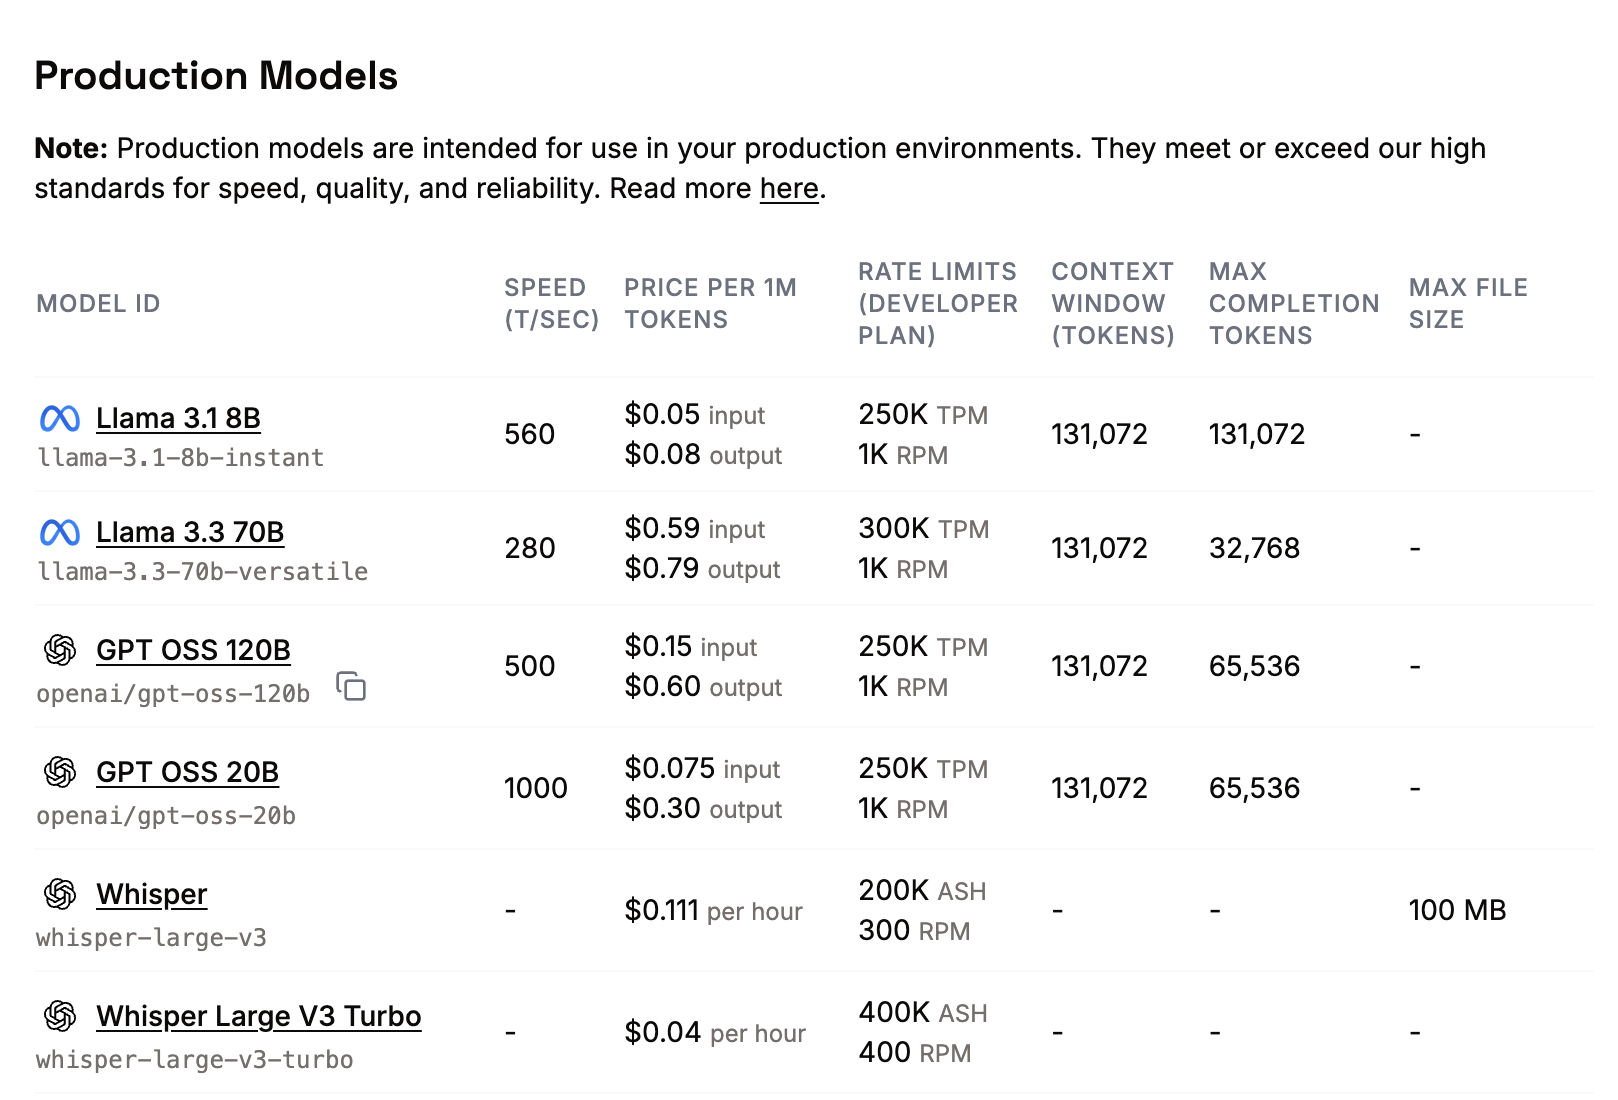

In [76]:
best_rerank_cfg = next(r for r in rerank_retr_results
                       if r['Эксперимент'] == 'BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50)')
best_ce_model = ce_cache[best_rerank_cfg['ce_short']]

def retrieve_winner(q):
    return retrieve_hybrid_rerank(q, best_ce_model, n_results=7,
                                   candidate_k=best_rerank_cfg['cand_k'], alpha=0.5)

In [ ]:
def generate_answer_with_model(query, chunks_context, model_id, max_tokens=600):
    prompt = f"""
        Answer the question below based on the context.
        Do not hallucinate; only use information from the context.

        Context:
        {chunks_context}

        Question:
        {query}

        Answer:
    """
    output = model.chat.completions.create(
        model=model_id,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=max_tokens,
        temperature=0.7,
    )
    return output.choices[0].message.content.strip()


def eval_generation_llm(name, retrieve_fn, llm_model_id, sleep_s=0.3):
    t0 = time.time()
    em, f1, sim, rl, lat = [], [], [], [], []
    for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc=name):
        chunks, _, metas = retrieve_fn(row['question'])
        context = build_context(chunks, metas)
        ts = time.time()
        try:
            ans = generate_answer_with_model(row['question'], context, llm_model_id)
        except Exception as e:
            print(f'  err: {e}'); ans = ''
        lat.append(time.time() - ts)
        ref = row['right_answer']
        em.append(int(normalize(ans) == normalize(ref)))
        f1.append(f1_tok(ans, ref))
        sim.append(gen_sim_metric(ans, ref))
        rl.append(rouge_l(ref, ans))
        time.sleep(sleep_s)
    return {
        'Эксперимент': name,
        'Exact Match': round(np.mean(em), 4),
        'F1': round(np.mean(f1), 4),
        'Gen. Sem. Sim.': round(np.mean(sim), 4),
        'ROUGE-L': round(np.mean(rl), 4),
        'Avg latency (сек)': round(np.mean(lat), 2),
        'Время поиска (сек)': round(time.time() - t0, 1),
    }


LLM_MODELS = [
    ('llama-3.3-70b', 'llama-3.3-70b-versatile'),
    ('gpt-oss-120b',  'openai/gpt-oss-120b'),
]

llm_results = []
for short_name, model_id in LLM_MODELS:
    print(f'\n{short_name} ({model_id}) ===')
    try:
        m = eval_generation_llm(
            f'BGE+Hybrid+CE (cand=50) + {short_name}',
            retrieve_winner,
            llm_model_id=model_id,
        )
        llm_results.append({**m, 'model_id': model_id, 'short_name': short_name})
        print(m)
    except Exception as e:
        print(f'Ошибка: {e}')

for m in llm_results:
    all_results.append({
        'Эксперимент': m['Эксперимент'],
        'Корпус': 'chroma_augmented_store',
        'Retrieval': 'BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-MiniLM-L12, cand=50)',

         # имя модели для генерации ответов
        'LLM': f'{m["model_id"]} (temp=0.7)',

        'Top-1 Acc.': best_rerank_cfg['Top-1 Acc.'],
        'Top-K Acc.': best_rerank_cfg['Top-K Acc.'],
        'Retr. Sem. Sim.': best_rerank_cfg['Retr. Sem. Sim.'],

        'Exact Match': m['Exact Match'],
        'F1': m['F1'],
        'Gen. Sem. Sim.': m['Gen. Sem. Sim.'],
        'ROUGE-L': m['ROUGE-L'],
        'Avg latency (сек)': m['Avg latency (сек)'],
        'Время поиска (сек)':  m['Время поиска (сек)'],
        'Время индексации (сек)': None,

        # имя эмбеддера
        'Модель':  'BAAI/bge-base-en-v1.5',
    })

In [78]:
pd.DataFrame(llm_results)

,Эксперимент,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),model_id,short_name
0,BGE+Hybrid+CE (cand=50) + llama-3.3-70b,0.0766,0.2533,0.4403,0.2348,2.13,565.2,llama-3.3-70b-versatile,llama-3.3-70b
1,BGE+Hybrid+CE (cand=50) + gpt-oss-120b,0.0225,0.1771,0.4087,0.1603,2.95,746.4,openai/gpt-oss-120b,gpt-oss-120b


In [83]:
pd.DataFrame([all_results[0], all_results[4], all_results[9], all_results[10]])

,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек),Модель
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,None,all-MiniLM-L6-v2
1,BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B,chroma_augmented_store,"Hybrid RRF (BM25 + BGE-base dense), α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.2117,0.5000,0.6421,0.0405,0.1850,0.3757,0.1664,2.33,15.2,None,BAAI/bge-base-en-v1.5
2,BGE+Hybrid+CE (cand=50) + llama-3.3-70b,chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.3-70b-versatile (temp=0.7),0.4324,0.5721,0.6463,0.0766,0.2533,0.4403,0.2348,2.13,565.2,None,BAAI/bge-base-en-v1.5
3,BGE+Hybrid+CE (cand=50) + gpt-oss-120b,chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,openai/gpt-oss-120b (temp=0.7),0.4324,0.5721,0.6463,0.0225,0.1771,0.4087,0.1603,2.95,746.4,None,BAAI/bge-base-en-v1.5


Llama-3.3-70B уверенно обогнала baseline. А вот GPT-OSS-120B неожиданно проиграла Llama-70B по всем generation-метрикам (Gen.Sim=0.41, F1=0.18) — несмотря на 120B параметров, на наш промпт без reasoning-режима она отвечает хуже Llama.


# Итоговая сводная таблица всех подходов

In [85]:
pd.DataFrame(all_results)

,Эксперимент,Корпус,Retrieval,LLM,Top-1 Acc.,Top-K Acc.,Retr. Sem. Sim.,Exact Match,F1,Gen. Sem. Sim.,ROUGE-L,Avg latency (сек),Время поиска (сек),Время индексации (сек),Модель
0,"Baseline (Semantic K=5, Чекпойнт 3)",chroma_augmented_store,"Semantic, MiniLM-L6, K=5",llama-3.1-8b-instant (temp=0.7),0.2162,0.3829,0.5647,0.0225,0.1447,0.3219,0.1304,2.14,76.5,NaN,all-MiniLM-L6-v2
1,"Best ML (Hybrid α=0.5, K=7, после Чекпоинта 5)",chroma_augmented_store,"Hybrid RRF, α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.1712,0.4685,0.5002,0.0360,0.1626,0.3553,0.1461,2.37,75.7,NaN,all-MiniLM-L6-v2
2,Emb: MPNet-base,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2387,0.3964,0.5954,NaN,NaN,NaN,NaN,NaN,10.9,1.1,sentence-transformers/all-mpnet-base-v2
3,Emb: BGE-base-en-v1.5,chroma_augmented_store,"Semantic, MiniLM-L6, K=5",NaN,0.2973,0.4369,0.6892,NaN,NaN,NaN,NaN,NaN,11.1,0.9,BAAI/bge-base-en-v1.5
4,BGE-base + Hybrid α=0.5 K=7 + Llama-3.1-8B,chroma_augmented_store,"Hybrid RRF (BM25 + BGE-base dense), α=0.5, K=7",llama-3.1-8b-instant (temp=0.7),0.2117,0.5000,0.6421,0.0405,0.1850,0.3757,0.1664,2.33,15.2,NaN,BAAI/bge-base-en-v1.5
5,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=20),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.1-8b-instant (temp=0.7),0.4189,0.5586,0.6559,NaN,NaN,NaN,NaN,NaN,20.6,NaN,ms-marco-MiniLM-L12
6,BGE+Hybrid+CE: ms-marco-MiniLM-L12 (cand=50),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.1-8b-instant (temp=0.7),0.4324,0.5721,0.6463,0.0450,0.2120,0.3851,0.1948,2.29,25.5,NaN,ms-marco-MiniLM-L12
7,BGE+Hybrid+CE: bge-reranker-base (cand=20),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (bge-rerank...,llama-3.1-8b-instant (temp=0.7),0.3198,0.5676,0.6467,NaN,NaN,NaN,NaN,NaN,28.6,NaN,bge-reranker-base
8,BGE+Hybrid+CE: bge-reranker-base (cand=50),chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (bge-rerank...,llama-3.1-8b-instant (temp=0.7),0.3198,0.5270,0.6293,NaN,NaN,NaN,NaN,NaN,50.6,NaN,bge-reranker-base
9,BGE+Hybrid+CE (cand=50) + llama-3.3-70b,chroma_augmented_store,BGE + Hybrid α=0.5 K=7 + CE rerank (ms-marco-M...,llama-3.3-70b-versatile (temp=0.7),0.4324,0.5721,0.6463,0.0766,0.2533,0.4403,0.2348,2.13,565.2,NaN,BAAI/bge-base-en-v1.5


# Выводы

В результате четырёх экспериментов мы получили RAG-пайплайн, который улучшает все 7 ключевых метрик относительно как изначального бейзлайна (Чекпойнт 3), так и лучшего достигнутого решения до чекпоинта 6 (чекпоинт 5).

**Финальная конфигурация:**
BGE-base-en-v1.5 (эмбеддер) → Hybrid RRF (BM25 + BGE, α=0.5) → Реранкер ms-marco-MiniLM-L-12-v2 (cand=50) → Llama-3.3-70B-versatile, K=7.

Главная метрика проекта - Generation Semantic Similarity - выросла с 0.3219 до 0.4403, retrieval Top-1 удвоился (0.22 -> 0.43), Top-K вырос с 0.38 до 0.57.

## **Что сработало и почему**
Замена эмбеддера (эксперимент 1) дала первый прирост: BGE-base обучен контрастивым методом, тогда как MiniLM-L6 обучался на NLI/STS. Промежуточный эксперимент с MPNet-base подтвердил, что специализация под retrieval важнее, чем просто увеличение размера модели (MPNet больше MiniLM, но слабее BGE).

Cross-encoder rerank (эксперимент 2) дал самый большой одношаговый прирост — Top-1 удвоился до 0.43, потому что реранкер прицельно ставит правильный чанк на первое место там, где энкодер ошибается из-за независимого кодирования.

Замена LLM на Llama-3.3-70B (эксперимент 3) показала, что baseline Llama-3.1-8B недоиспользовала улучшенный контекст, тк 70B-модель вытянула из того же ретривера ещё +0.055 Gen.Sim.



## **Что не сработало**

Модель OpenAI GPT-OSS-120B (эксперимент 3) неожиданно проиграла Llama-70B по всем метрикам, несмотря на 120B параметров и MoE-архитектуру.

